In [1]:
import pandas as pd

df = pd.read_csv(r"D:\Guvi\Projects\Telecom_ai_brand_system\customer-support-on-twitter\twcs\twcs.csv")

print(df.shape)
df.head()

(2811774, 7)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [2]:
df = df[['text']]

df.head()

,text
0,@115712 I understand. I would like to assist y...
1,@sprintcare and how do you propose we do that
2,@sprintcare I have sent several private messag...
3,@115712 Please send us a Private Message so th...
4,@sprintcare I did.


In [3]:
df.rename(columns={'text': 'Feedback_Text'}, inplace=True)

df.head()

,Feedback_Text
0,@115712 I understand. I would like to assist y...
1,@sprintcare and how do you propose we do that
2,@sprintcare I have sent several private messag...
3,@115712 Please send us a Private Message so th...
4,@sprintcare I did.


In [4]:
df.dropna(inplace=True)

print(df.isnull().sum())

Feedback_Text    0
dtype: int64


In [5]:
df.drop_duplicates(inplace=True)

print(df.shape)

(2782618, 1)


In [6]:
import re

def clean_text(text):
    text = text.lower()
    
    text = re.sub(r"http\S+", "", text)
    
    text = re.sub(r"@\w+", "", text)
    
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df['Clean_Text'] = df['Feedback_Text'].apply(clean_text)

df.head()

,Feedback_Text,Clean_Text
0,@115712 I understand. I would like to assist y...,i understand i would like to assist you we wou...
1,@sprintcare and how do you propose we do that,and how do you propose we do that
2,@sprintcare I have sent several private messag...,i have sent several private messages and no on...
3,@115712 Please send us a Private Message so th...,please send us a private message so that we ca...
4,@sprintcare I did.,i did


In [7]:
df = df[df['Clean_Text'].str.len() > 10]

print(df.shape)

(2696827, 2)


In [8]:
!pip install transformers


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\admin\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [10]:
sample_df = df.sample(1000, random_state=42)

In [11]:
def get_sentiment(text):
    result = sentiment_pipeline(text[:512])[0]
    
    label = result['label']
    
    if label == 'POSITIVE':
        return 'Positive'
    else:
        return 'Negative'

sample_df['Sentiment'] = sample_df['Clean_Text'].apply(get_sentiment)

sample_df.head()

,Feedback_Text,Clean_Text,Sentiment
817501,@VirginTrains loving the train manager on the ...,loving the train manager on the from euston to...,Positive
1091922,Erneut wird ne Kleinigkeit von Amazon aus Chin...,erneut wird ne kleinigkeit von amazon aus chin...,Negative
1514009,@506756 https://t.co/lPUO2k26eo to view our ta...,to view our tariff plans that best suits your ...,Negative
2473653,@529522 Hello Frank! I see we have a DM from ...,hello frank i see we have a dm from you i will...,Positive
1996104,@338424 Hey there. Can you tell us what you ar...,hey there can you tell us what you are referri...,Negative


In [12]:
def detect_category(text):
    text = text.lower()
    
    if any(word in text for word in ['internet', 'wifi', 'broadband']):
        return 'Broadband Service'
    
    elif any(word in text for word in ['bill', 'payment', 'charge']):
        return 'Billing & Payments'
    
    elif any(word in text for word in ['support', 'help']):
        return 'Customer Support'
    
    elif any(word in text for word in ['sim', 'activation']):
        return 'Service Activation'
    
    elif any(word in text for word in ['app', 'login']):
        return 'Mobile App Issues'
    
    else:
        return 'Mobile Network'

sample_df['Service_Category'] = sample_df['Clean_Text'].apply(detect_category)

sample_df.head()

,Feedback_Text,Clean_Text,Sentiment,Service_Category
817501,@VirginTrains loving the train manager on the ...,loving the train manager on the from euston to...,Positive,Mobile Network
1091922,Erneut wird ne Kleinigkeit von Amazon aus Chin...,erneut wird ne kleinigkeit von amazon aus chin...,Negative,Mobile Network
1514009,@506756 https://t.co/lPUO2k26eo to view our ta...,to view our tariff plans that best suits your ...,Negative,Mobile Network
2473653,@529522 Hello Frank! I see we have a DM from ...,hello frank i see we have a dm from you i will...,Positive,Billing & Payments
1996104,@338424 Hey there. Can you tell us what you ar...,hey there can you tell us what you are referri...,Negative,Service Activation


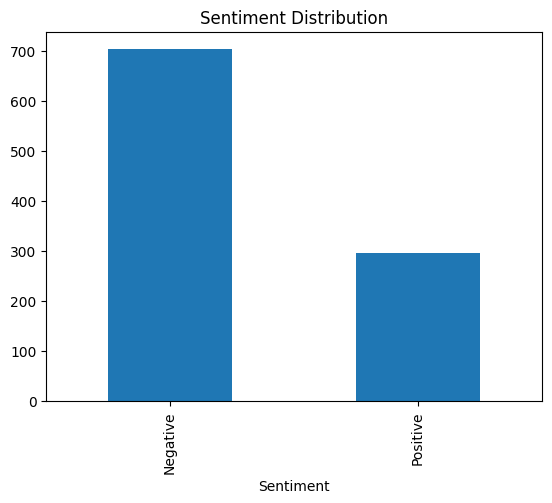

In [13]:
import matplotlib.pyplot as plt

sample_df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")

plt.show()

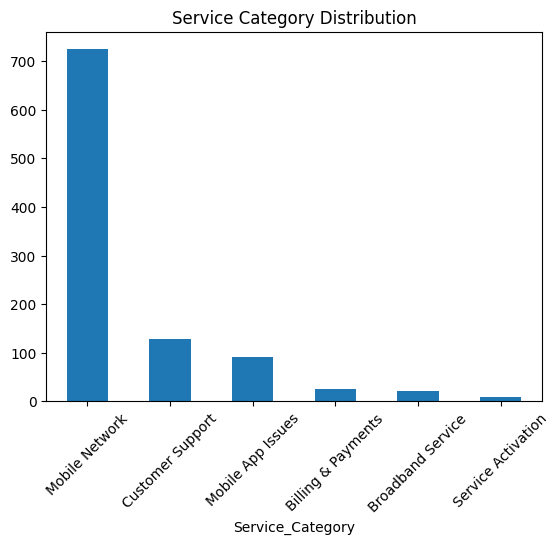

In [14]:
sample_df['Service_Category'].value_counts().plot(kind='bar')

plt.title("Service Category Distribution")

plt.xticks(rotation=45)

plt.show()

In [15]:
sample_df.to_csv("telecom_ai_dataset.csv", index=False)

In [1]:
import sys
print(sys.executable)

C:\Users\admin\AppData\Local\Programs\Python\Python313\python.exe
